___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright by Pierian Data Inc.</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>


# Manually Creating a DQN Model


## Deep-Q-Learning
In this notebook we will create our first Deep Reeinforcement Learning model, called Deep-Q-Network (DQN)
We are again using a simple environment from openai gym. <br />
However, you will soon see the enormous gain we will get by switching from standard Q-Learning to Deep Q Learning.

In this notebook we again take a look at the CartPole problem (https://gym.openai.com/envs/CartPole-v1/)



Let us start by importing the necessary packages

# Part 0: Imports

Notice how we're importing the TF libraries here at the top together, in some rare instances, if you import them later on, you get strange bugs, so best just to import everything from Tensorflow here at the top.

In [1]:
from collections import deque
import random
import time

In [2]:
import numpy as np

In [3]:
import gymnasium as gym

In [4]:
from tensorflow.keras.models import Sequential , clone_model
from tensorflow.keras.layers import Dense , Activation
from tensorflow.keras.optimizers import Adam

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

%config InlineBackened.figure_format = "retina"

# Part 1: The Environment

In [7]:
env_name = 'CartPole-v1'

Remember, the goal of the CartPole challenge was to balance the stick upright

In [8]:
env = gym.make(id = env_name , render_mode = "human")
state , info = env.reset()

for _ in range(100):
    env.render()
    action = env.action_space.sample()
    env.step(action)
    #time.sleep(0.1)
env.close()

In [9]:
%matplotlib inline

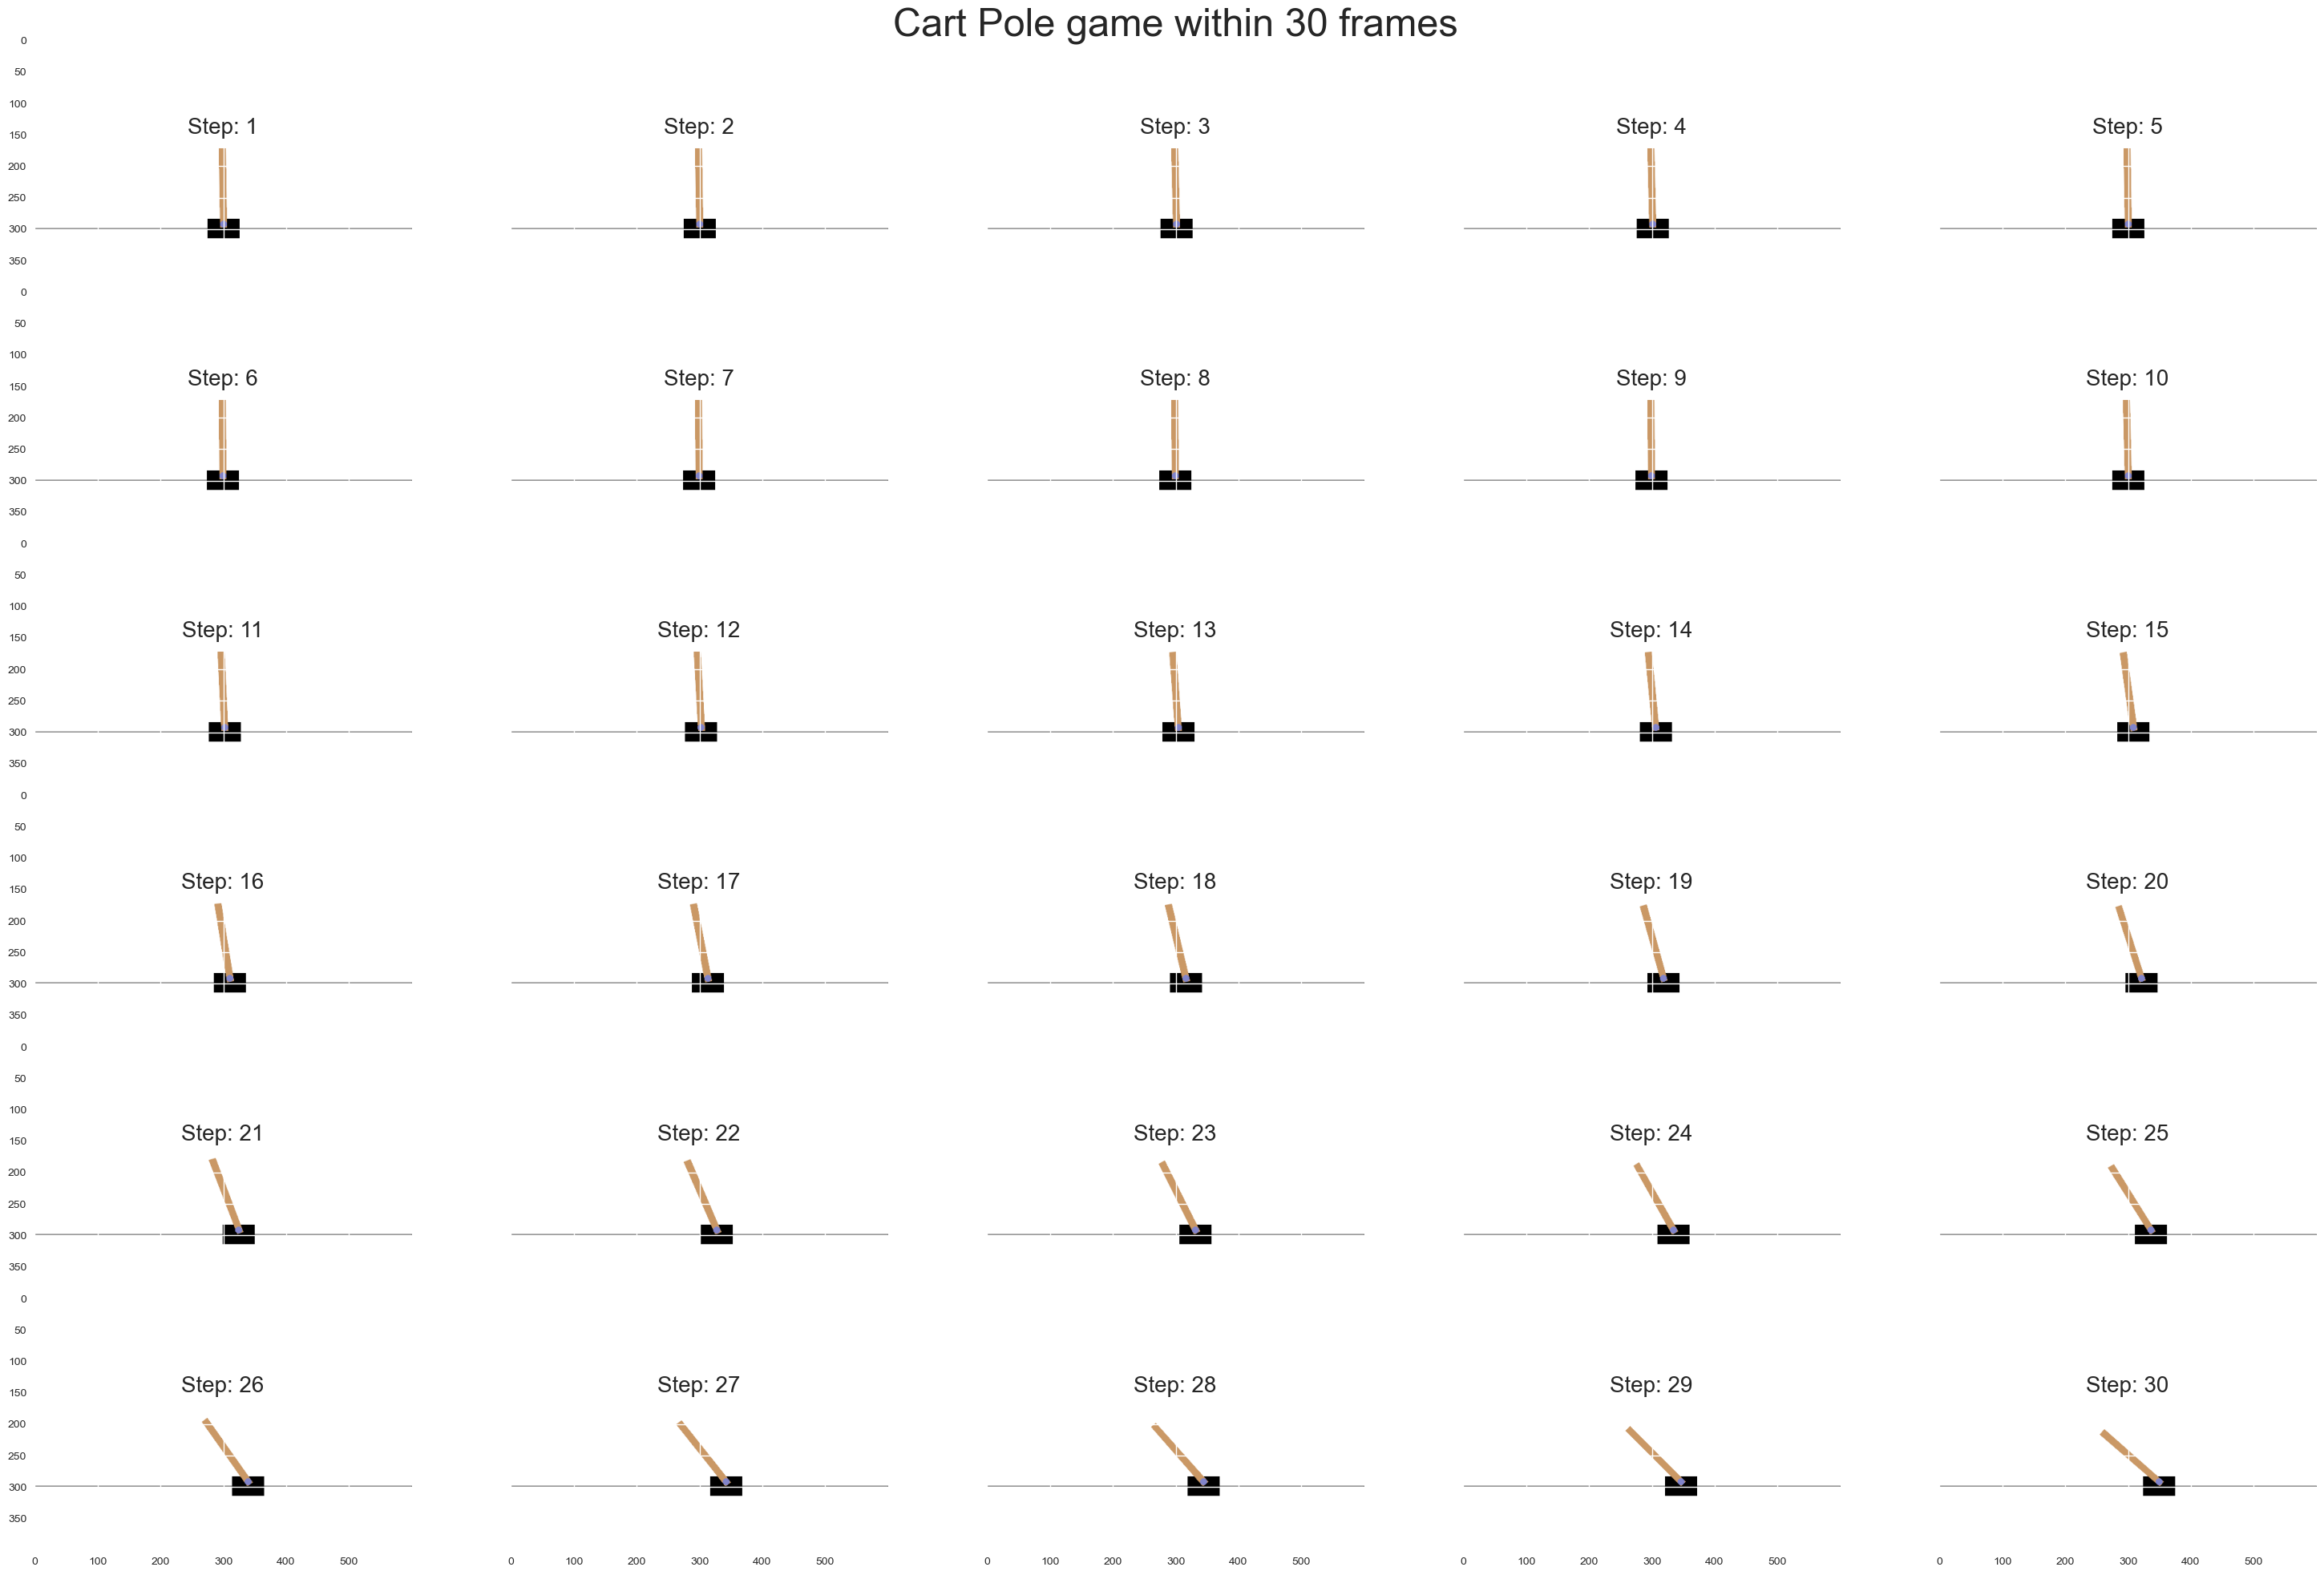

In [10]:
env = gym.make(id = env_name , render_mode = "rgb_array")
state , info = env.reset()

fig , ax = plt.subplots(figsize = (30,20) , nrows = 6 , ncols = 5, constrained_layout=True , sharex = "all" , sharey =  "all")
ax_flat = ax.flatten()

for i in range(30):
    frame = env.render()
    action = env.action_space.sample()
    new_state , reward , terminated , truncated , info = env.step(action)
    state = new_state

    ax_flat[i].imshow(frame, cmap = "plasma")
    ax_flat[i].set_title(f"Step: {i+1}" , y = 0.6 , fontsize = 20)
    ax_flat[i].axis("on")

fig.suptitle(t = "Cart Pole game within 30 frames", fontsize = 35)
fig.tight_layout()
fig.subplots_adjust(hspace=0.001 , wspace= .00001)
plt.show()

env.close()

# Part 2: The Artificial Neural Network

### Let us build our first Neural Network
To build our network, we first need to find out how many actions and observation our environment has.
We can either get those information from the source code (https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py) or via the following commands:

In [11]:
num_actions = env.action_space.n
num_observations = env.observation_space.shape[0]  # You can use this command to get the number of observations
print(f"There are {num_actions} possible actions and {num_observations} observations.")

There are 2 possible actions and 4 observations.


So our network needs to have an input dimension of 4 and an output dimension of 2.
In between we are free to chose.

Let's just say we want to use a four layer architecture:


1. The first layer has 16 neurons
2. The second layer has 32 neurons
4. The fourth layer (output layer) has 2 neurons

This yields 690 parameters
$$ \text{4 observations} * 16 (\text{neurons}) + 16 (\text{bias}) + (16*32) + 32 + (32*2)+2 = 690$$

In [12]:
num_actions.is_integer() , num_actions

(True, np.int64(2))

In [13]:
int(num_actions)

2

In [14]:
model = Sequential()

model.add(Dense(units=16 , input_shape = (num_observations,)))
model.add(Activation(activation="relu"))

model.add(Dense(units = 32))
model.add(Activation(activation="relu"))

model.add(Dense(units= int(num_actions)))
model.add(Activation(activation="linear"))

In [15]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 690 (2.70 KB)

 Trainable params: 690 (2.70 KB)

 Non-trainable params: 0 (0.00 B)

None


Now we have our model which takes an observation as input and outputs a value for each action.
The higher the value, the more likely that this value is a suitable action for the current observation

As stated in the lecture, Deep-Q-Learning works better when using a target network.
So let's just copy the above network

In [16]:
#model.load_weights("34.ckt")
target_model = clone_model(model)

Now it is time to define our hyperparameters.

# Part 3: Hyperparameters and Update Function

In [17]:
EPOCHS = 1000

epsilon = 1.0
EPSILON_REDUCE = 0.995  # is multiplied with epsilon each epoch to reduce it
LEARNING_RATE = 0.001 #NOT THE SAME AS ALPHA FROM Q-LEARNING FROM BEFORE!!
GAMMA = 0.95

Let us use the epsilon greedy action selection function once again:

In [18]:
def epsilon_greedy_action_selection(model, epsilon, observation, action_dim):
    if np.random.random() > epsilon:
        observation = np.array(observation, dtype=np.float32).reshape(1, -1)
        prediction = model(observation, training = False)
        action = np.argmax(prediction)
    else:
        action = np.random.randint(0, action_dim)
    return action   

In [19]:
# def epsilon_greedy_action_selection(model, epsilon, observation):
#     if np.random.random() > epsilon:
#         prediction = model(observation)  # perform the prediction on the observation
#         action = np.argmax(prediction)  # Chose the action with the higher value
#     else:
#         action = np.random.randint(0, int(env.action_space.n))  # Else use random action
#     return action

As shown in the lecture, we need a replay buffer.
We can use the **deque** data structure for this, which already implements the circular behavior.

The *maxlen* argument specifies the number of elements the buffer can store between he overwrites them at the beginning

The following cell shows an example usage of the deque function. You can see, that in the first example all values fit into the deque, so nothing is overwritten. 

In the second example, the deque is printed in each iteration. It can hold all values in the first five iterations but then needs to delete the oldest value in the deque to make room for the new value 

In [20]:
deque_1 = deque(maxlen=5)
deque_1

deque([], maxlen=5)

In [21]:
for i in range(5):
    deque_1.append(i)
    print(deque_1)

deque([0], maxlen=5)
deque([0, 1], maxlen=5)
deque([0, 1, 2], maxlen=5)
deque([0, 1, 2, 3], maxlen=5)
deque([0, 1, 2, 3, 4], maxlen=5)


In [22]:
deque_1 = deque(maxlen=5)
deque_1

deque([], maxlen=5)

In [23]:
for i in range(3):
    deque_1.append(i)
    print(deque_1)

deque([0], maxlen=5)
deque([0, 1], maxlen=5)
deque([0, 1, 2], maxlen=5)


In [24]:
deque_1 = deque(maxlen=5)
deque_1

deque([], maxlen=5)

In [25]:
for i in range(10):
    deque_1.append(i)
    print(deque_1)

deque([0], maxlen=5)
deque([0, 1], maxlen=5)
deque([0, 1, 2], maxlen=5)
deque([0, 1, 2, 3], maxlen=5)
deque([0, 1, 2, 3, 4], maxlen=5)
deque([1, 2, 3, 4, 5], maxlen=5)
deque([2, 3, 4, 5, 6], maxlen=5)
deque([3, 4, 5, 6, 7], maxlen=5)
deque([4, 5, 6, 7, 8], maxlen=5)
deque([5, 6, 7, 8, 9], maxlen=5)


In [26]:
### deque examples
deque_1 = deque(maxlen=5)
for i in range(5):  # all values fit into the deque, no overwriting
    deque_1.append(i)
print(deque_1)
print("---------------------")


deque_2 = deque(maxlen=5)
# after the first 5 values are stored, it needs to overwrite the oldest value to store the new one
for i in range(10):  
    deque_2.append(i)
    print(deque_2)

deque([0, 1, 2, 3, 4], maxlen=5)
---------------------
deque([0], maxlen=5)
deque([0, 1], maxlen=5)
deque([0, 1, 2], maxlen=5)
deque([0, 1, 2, 3], maxlen=5)
deque([0, 1, 2, 3, 4], maxlen=5)
deque([1, 2, 3, 4, 5], maxlen=5)
deque([2, 3, 4, 5, 6], maxlen=5)
deque([3, 4, 5, 6, 7], maxlen=5)
deque([4, 5, 6, 7, 8], maxlen=5)
deque([5, 6, 7, 8, 9], maxlen=5)


Let's say we allow our replay buffer a maximum size of 20000

In [27]:
replay_buffer = deque(maxlen=20000)
update_target_model = 10

As mentioned in the lecture, action replaying is crucial for Deep Q-Learning. <br />
The following cell implements one version of the action replay algorithm. <br />
It uses the zip statement paired with the * (Unpacking Argument Lists) operator to create batches from the samples for efficient prediction and training.<br />
The zip statement returns all corresponding pairs from each entry. <br />
It might look confusing but the following example should clarify it

In [28]:
test_tuple = [(1, 2, 3), (4, 5, 6), (7, 8, 9)]
test_tuple

[(1, 2, 3), (4, 5, 6), (7, 8, 9)]

In [29]:
zip(*test_tuple)

In [30]:
list(zip(*test_tuple))

[(1, 4, 7), (2, 5, 8), (3, 6, 9)]

In [31]:
test_tuple = [(1, 2, 3), (4, 5, 6), (7, 8, 9)]
zipped_list = list(zip(*test_tuple))
a, b, c = zipped_list
print(a, b, c)

(1, 4, 7) (2, 5, 8) (3, 6, 9)


Now it's time to write the replay function

In [32]:
def replay(replay_buffer, batch_size, model, target_model):
    
    # As long as the buffer has not enough elements we do nothing
    if len(replay_buffer) < batch_size: 
        return
    
    # Take a random sample from the buffer with size batch_size
    samples = random.sample(replay_buffer, batch_size)  
    
    # to store the targets predicted by the target network for training
    target_batch = []  
    
    # Efficient way to handle the sample by using the zip functionality
    zipped_samples = list(zip(*samples))  
    states, actions, rewards, new_states, dones = zipped_samples  
    
    # Predict targets for all states from the sample
    targets = target_model.predict(np.array(states) , verbose = 0)
    
    # Predict Q-Values for all new states from the sample
    q_values = model.predict(np.array(new_states) , verbose = 0)  
    
    # Now we loop over all predicted values to compute the actual targets
    for i in range(batch_size):
        # Take the maximum Q-Value for each sample (over the action dimension)
        q_value = np.max(q_values[i])
    
        target = targets[i].copy()
        if dones[i]:
            target[actions[i]] = rewards[i]
        else:
            target[actions[i]] = rewards[i] + q_value * GAMMA
        target_batch.append(target)

    # Fit the model based on the states and the updated targets for 1 epoch
    model.fit(np.array(states), np.array(target_batch), epochs=1, verbose=0)  

We need to update our target network every once in a while. <br />
Keras provides the *set_weights()* and *get_weights()* methods which do the work for us, so we only need to check whether we hit an update epoch

In [33]:
def update_model_handler(epoch, update_target_model, model, target_model):
    if epoch > 0 and epoch % update_target_model == 0:
        target_model.set_weights(model.get_weights())


# Part 4: Training the Model

Now it is time to write the training loop! <br />
First we compile the model

In [34]:
model.compile(loss='mse', optimizer=Adam(learning_rate=LEARNING_RATE))

In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 690 (2.70 KB)

 Trainable params: 690 (2.70 KB)

 Non-trainable params: 0 (0.00 B)

Then we perform the training routine. <br />
This might take some time, so make sure to grab your favorite beverage and watch your model learn. <br />
Feel free to use our provided chekpoints as a starting point

In [36]:
best_so_far = 0
for epoch in range(EPOCHS):
    observation , info = env.reset()  # Get inital state
    
    # Keras expects the input to be of shape [1, X] thus we have to reshape
    observation = observation.reshape([1, 4])  
    done = False  
    
    points = 0
    while not done:  # as long current run is active
        
        # Select action acc. to strategy
        action = epsilon_greedy_action_selection(model, epsilon, observation, env.action_space.n)   
        
        # Perform action and get next state
        next_observation, reward, truncated , terminated , info = env.step(action)
        next_observation = next_observation.reshape([1, 4])  # Reshape!!
        done = terminated or truncated
        replay_buffer.append((observation.flatten() , action , reward , next_observation.flatten() , done))  # Update the replay buffer
        observation = next_observation  # update the observation
        points+=1

        # Most important step! Training the model by replaying
        replay(replay_buffer, 32, model, target_model)

    
    epsilon *= EPSILON_REDUCE  # Reduce epsilon
    
    # Check if we need to update the target model
    update_model_handler(epoch, update_target_model, model, target_model)
    
    if points > best_so_far:
        best_so_far = points
    if epoch %25 == 0:
        print(f"{epoch}: Points reached: {points} - epsilon: {epsilon} - Best: {best_so_far}")

0: Points reached: 71 - epsilon: 0.995 - Best: 71
25: Points reached: 15 - epsilon: 0.8778091417340573 - Best: 71
50: Points reached: 13 - epsilon: 0.7744209942832988 - Best: 71
75: Points reached: 31 - epsilon: 0.6832098777212641 - Best: 108
100: Points reached: 150 - epsilon: 0.6027415843082742 - Best: 150
125: Points reached: 28 - epsilon: 0.531750826943791 - Best: 180
150: Points reached: 99 - epsilon: 0.46912134373457726 - Best: 198
175: Points reached: 129 - epsilon: 0.41386834584198684 - Best: 245
200: Points reached: 21 - epsilon: 0.36512303261753626 - Best: 267


KeyboardInterrupt: 

# Part 5: Using Trained Model

In [40]:
env = gym.make(id = env_name , render_mode = "human")
state , info = env.reset()

for _ in range(100):
    env.render()
    action = env.action_space.sample()
    env.step(action)
    #time.sleep(0.1)
env.close()

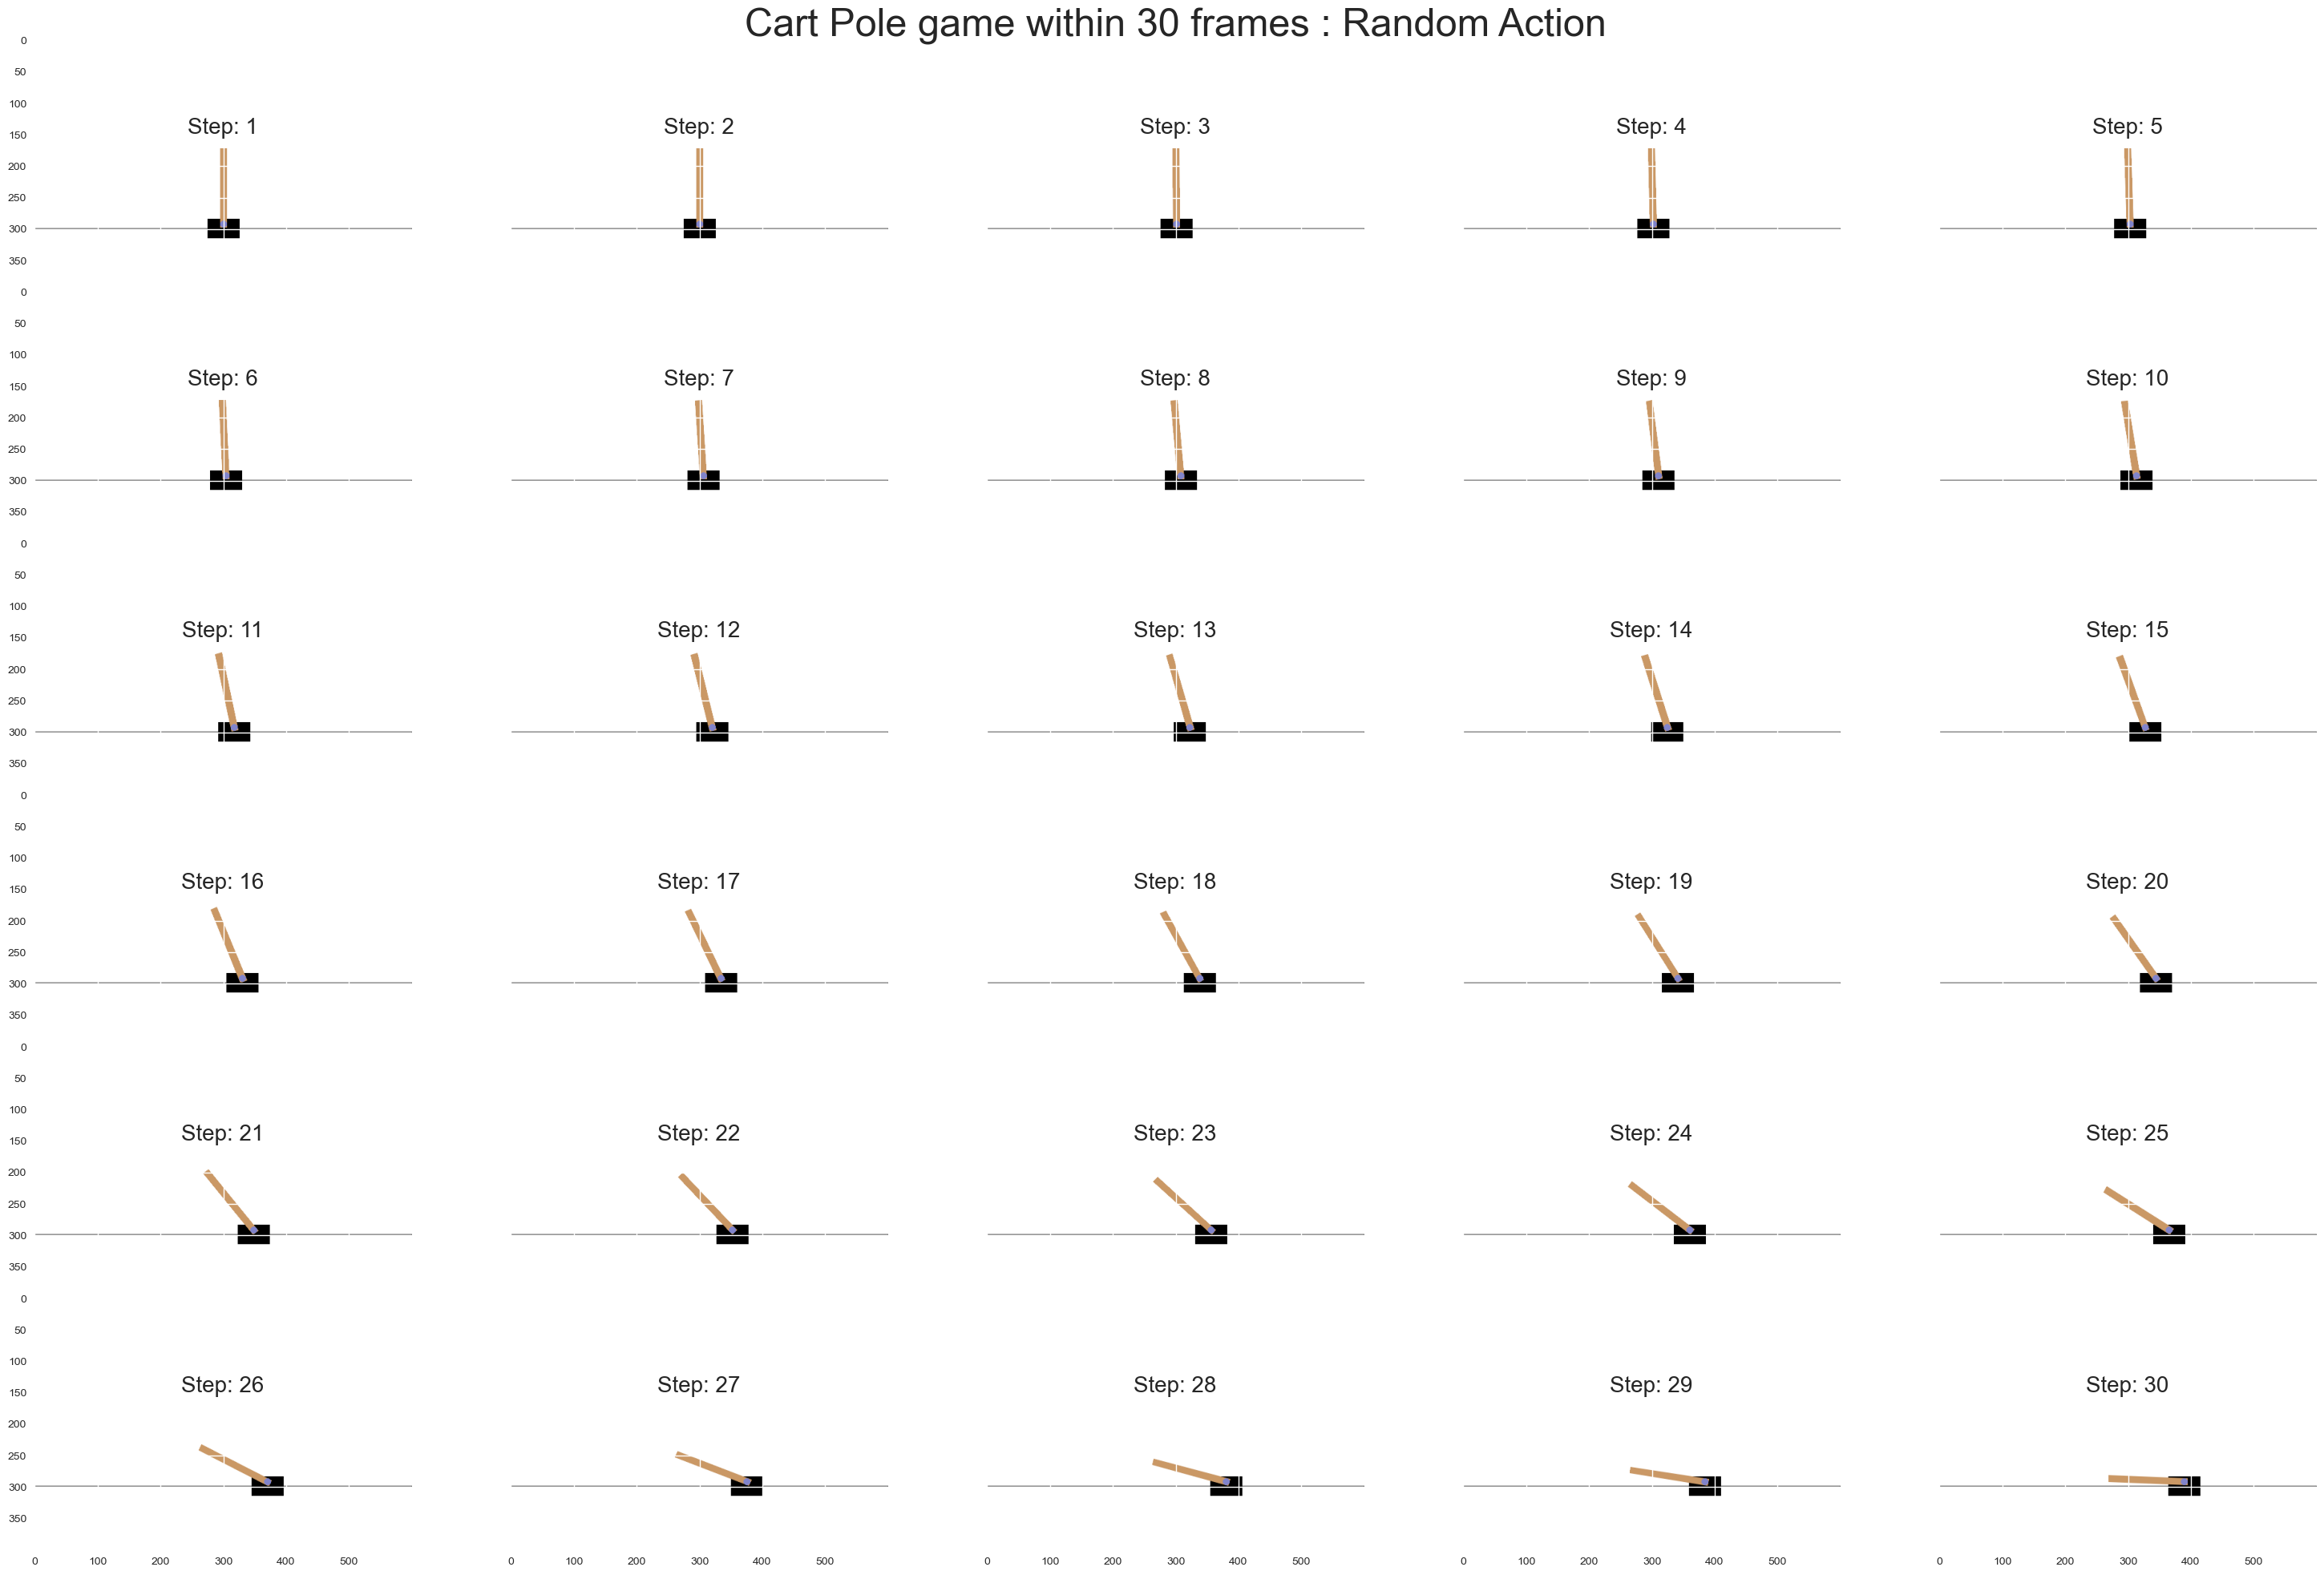

In [46]:
env = gym.make(id = env_name , render_mode = "rgb_array")
state , info = env.reset()

fig , ax = plt.subplots(figsize = (30,20) , nrows = 6 , ncols = 5, constrained_layout=True , sharex = "all" , sharey =  "all")
ax_flat = ax.flatten()

for i in range(30):
    frame = env.render()
    action = env.action_space.sample()
    new_state , reward , terminated , truncated , info = env.step(action)
    state = new_state

    ax_flat[i].imshow(frame, cmap = "plasma")
    ax_flat[i].set_title(f"Step: {i+1}" , y = 0.6 , fontsize = 20)
    ax_flat[i].axis("on")

fig.suptitle(t = "Cart Pole game within 30 frames : Random Action", fontsize = 35)
fig.tight_layout()
fig.subplots_adjust(hspace=0.001 , wspace= .00001)
plt.show()

env.close()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━

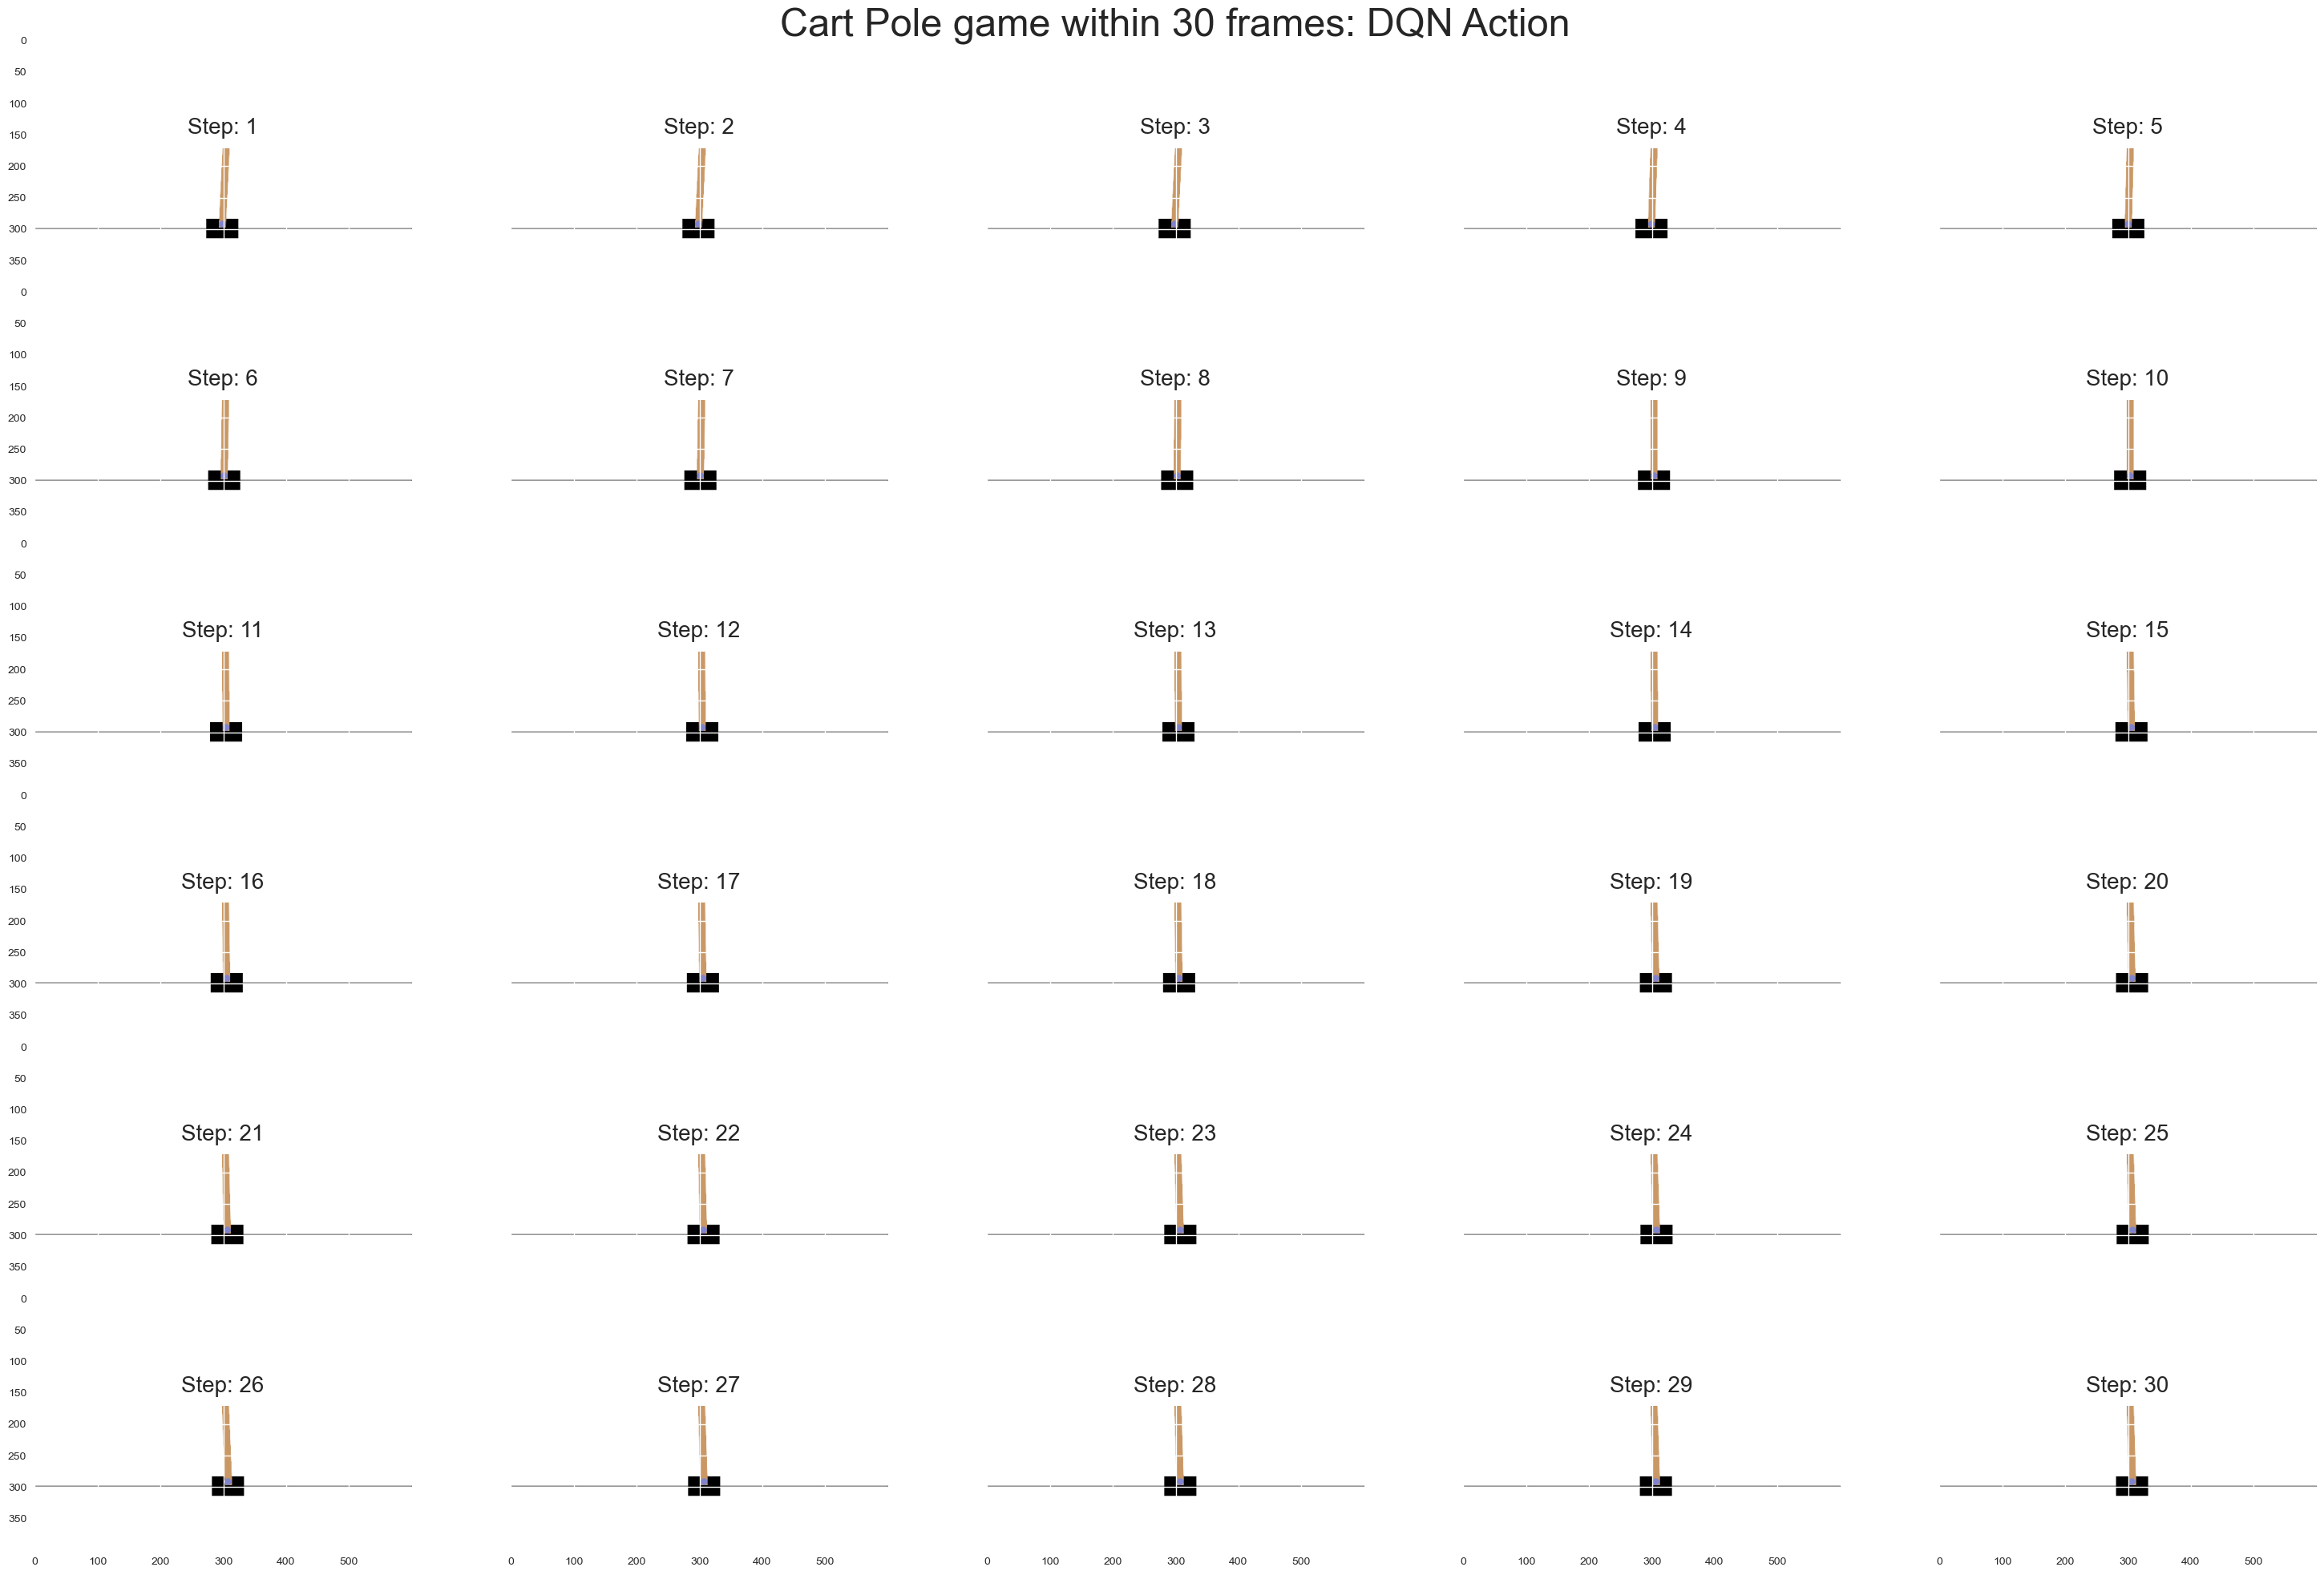

In [47]:
env = gym.make(id = env_name , render_mode = "rgb_array")
observation , info = env.reset()

fig , ax = plt.subplots(figsize = (30,20) , nrows = 6 , ncols = 5, constrained_layout=True , sharex = "all" , sharey =  "all")
ax_flat = ax.flatten()


for i in range(30):
    frame = env.render()
    # TODO: Get discretized observation
    action = np.argmax(model.predict(observation.reshape([1,4])))
    
    # TODO: Perform the action 
    observation, reward, truncated ,terminated , info = env.step(action) # Finally perform the action
    done = truncated or terminated

    ax_flat[i].imshow(frame, cmap = "plasma")
    ax_flat[i].set_title(f"Step: {i+1}" , y = 0.6 , fontsize = 20)
    ax_flat[i].axis("on")

fig.suptitle(t = "Cart Pole game within 30 frames: DQN Action", fontsize = 35)
fig.tight_layout()
fig.subplots_adjust(hspace=0.001 , wspace= .00001)
plt.show()
    
env.close()

In [41]:
env = gym.make(id = env_name , render_mode = "human")
observation , info = env.reset()
for counter in range(300):
    env.render()
    
    # TODO: Get discretized observation
    action = np.argmax(model.predict(observation.reshape([1,4])))
    
    # TODO: Perform the action 
    observation, reward, truncated ,terminated , info = env.step(action) # Finally perform the action
    done = truncated or terminated
    
    if done:
        print(f"done")
        break
env.close()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━